In [23]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# 各パス指定

In [24]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'

# 分類数設定

In [25]:
NUM_CLASSES = 38


# 学習データ読み込み

In [26]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [27]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# モデル構築

In [29]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [30]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_2 (Dropout)         (None, 42)                0         
                                                                 
 dense_3 (Dense)             (None, 20)                860       
                                                                 
 dropout_3 (Dropout)         (None, 20)                0         
                                                                 
 dense_4 (Dense)             (None, 10)                210       
                                                                 
 dense_5 (Dense)             (None, 38)                418       
                                                                 
Total params: 1488 (5.81 KB)
Trainable params: 1488 (5.81 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [31]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [32]:
# モデルコンパイル
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [33]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
20/20 [==============================] - ETA: 0s - loss: 3.6610 - accuracy: 0.0328
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
20/20 [==============================] - 7s 87ms/step - loss: 3.6610 - accuracy: 0.0328 - val_loss: 3.5974 - val_accuracy: 0.0715
Epoch 2/1000
 5/20 [======>.......................] - ETA: 0s - loss: 3.6114 - accuracy: 0.0469

c:\Users\mohammed\ProjectStart\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


18/20 [==========================>...] - ETA: 0s - loss: 3.5937 - accuracy: 0.0464
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
20/20 [==============================] - 1s 34ms/step - loss: 3.5924 - accuracy: 0.0469 - val_loss: 3.5485 - val_accuracy: 0.1333
Epoch 3/1000
18/20 [==========================>...] - ETA: 0s - loss: 3.5411 - accuracy: 0.0525
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
20/20 [==============================] - 1s 29ms/step - loss: 3.5391 - accuracy: 0.0534 - val_loss: 3.4948 - val_accuracy: 0.0897
Epoch 4/1000
18/20 [==========================>...] - ETA: 0s - loss: 3.4835 - accuracy: 0.0660
Epoch 4: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
20/20 [==============================] - 1s 31ms/step - loss: 3.4808 - accuracy: 0.0667 - val_loss: 3.4250 - val_accuracy: 0.0861
Epoch 5/1000
20/20 [==============================] - ETA: 0s - loss: 3.4156 - accuracy: 0.0850
Epoch 5: sa

In [34]:
# モデル評価
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

7/7 [==============================] - 0s 11ms/step - loss: 0.6948 - accuracy: 0.8667


In [35]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [36]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 1s 949ms/step
[1.23136374e-06 1.28017756e-08 1.16174556e-17 2.25949681e-09
 2.86961085e-06 2.56247236e-04 7.47138495e-03 8.18599801e-05
 3.57420156e-08 8.86516744e-08 2.39461118e-09 4.64362529e-05
 3.95237759e-04 4.56346804e-03 8.52869600e-02 2.33831140e-12
 1.50358241e-13 5.28905322e-11 2.44915009e-13 3.26217472e-04
 1.16136645e-04 6.74779876e-09 3.28399998e-04 1.06323607e-01
 8.80016842e-07 1.62644064e-04 2.66217481e-04 7.94369757e-01
 1.08519478e-08 1.35695898e-18 1.02877996e-14 6.82263313e-15
 5.88120492e-16 3.87227431e-17 5.93379998e-17 1.12151900e-16
 2.20281382e-18 3.33848874e-07]
27


# 混同行列

26/26 [==============================] - 0s 9ms/step


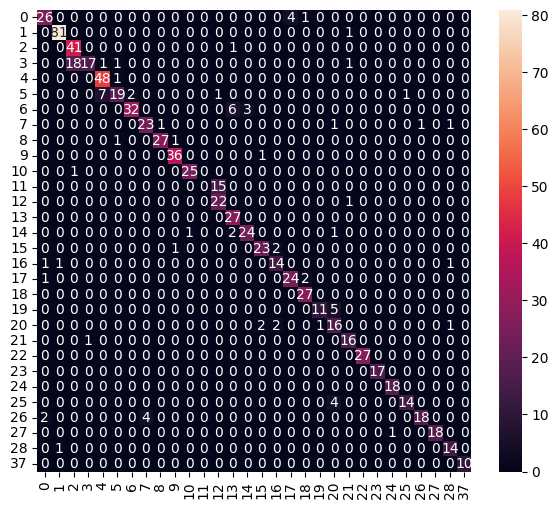

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.84      0.85        31
           1       0.98      0.99      0.98        82
           2       0.68      0.98      0.80        42
           3       0.94      0.45      0.61        38
           4       0.86      0.98      0.91        49
           5       0.86      0.63      0.73        30
           6       0.94      0.78      0.85        41
           7       0.85      0.85      0.85        27
           8       0.96      0.93      0.95        29
           9       0.95      0.97      0.96        37
          10       0.96      0.96      0.96        26
          11       0.00      0.00      0.00        15
          12       0.58      0.96      0.72        23
          13       0.75      1.00      0.86        27
          14       0.89      0.86      0.87        28
          15       0.88      0.88      0.88        26
          16       0.78      0.82      0.80        17
     

c:\Users\mohammed\ProjectStart\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mohammed\ProjectStart\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mohammed\ProjectStart\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Tensorflow-Lite用のモデルへ変換

In [38]:
# 推論専用のモデルとして保存
model.save(model_save_path, include_optimizer=False)

c:\Users\mohammed\ProjectStart\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [39]:
# モデルを変換(量子化)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\mohammed\AppData\Local\Temp\tmptnmj529l\assets


INFO:tensorflow:Assets written to: C:\Users\mohammed\AppData\Local\Temp\tmptnmj529l\assets


8084

# 推論テスト

In [40]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [41]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [42]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [43]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [44]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.23136101e-06 1.28017712e-08 1.16174514e-17 2.25949637e-09
 2.86961017e-06 2.56247178e-04 7.47138355e-03 8.18600383e-05
 3.57420049e-08 8.86516602e-08 2.39461051e-09 4.64362856e-05
 3.95238021e-04 4.56347363e-03 8.52870271e-02 2.33830620e-12
 1.50358201e-13 5.28904143e-11 2.44914928e-13 3.26217851e-04
 1.16136725e-04 6.74779654e-09 3.28400231e-04 1.06323577e-01
 8.80014909e-07 1.62644181e-04 2.66217656e-04 7.94369578e-01
 1.08519442e-08 1.35694813e-18 1.02877767e-14 6.82263059e-15
 5.88115781e-16 3.87227299e-17 5.93377549e-17 1.12151424e-16
 2.20280472e-18 3.33848135e-07]
27
